In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

def save_answer(filename, answer_str):
    with open(filename, 'w', encoding='utf-8') as f:
        f.write(str(answer_str).strip())
    print(f"Ответ для '{filename}' успешно сохранен: {answer_str}")

df = pd.read_csv('abalone.csv')
df['Sex'] = df['Sex'].map(lambda x: 1 if x == 'M' else (-1 if x == 'F' else 0))

X, y = df.drop(columns=['Rings']).values, df['Rings'].values
kf = KFold(n_splits=5, shuffle=True, random_state=1)

min_trees = None
for trees in range(1, 51):
    r2 = np.mean(cross_val_score(RandomForestRegressor(n_estimators=trees, random_state=1), X, y, cv=kf, scoring='r2'))
    print(f"Деревьев: {trees:2d} | Средний R2: {r2:.4f}")
    if r2 > 0.52 and min_trees is None:
        min_trees = trees

save_answer('forest_ans1.txt', min_trees)
print(f"\n--- Финальная проверка ---\nМинимальное количество деревьев для R2 > 0.52: {min_trees}")

Деревьев:  1 | Средний R2: 0.1097
Деревьев:  2 | Средний R2: 0.3413
Деревьев:  3 | Средний R2: 0.4064
Деревьев:  4 | Средний R2: 0.4448
Деревьев:  5 | Средний R2: 0.4650
Деревьев:  6 | Средний R2: 0.4714
Деревьев:  7 | Средний R2: 0.4767
Деревьев:  8 | Средний R2: 0.4829
Деревьев:  9 | Средний R2: 0.4894
Деревьев: 10 | Средний R2: 0.4954
Деревьев: 11 | Средний R2: 0.4944
Деревьев: 12 | Средний R2: 0.4990
Деревьев: 13 | Средний R2: 0.5031
Деревьев: 14 | Средний R2: 0.5073
Деревьев: 15 | Средний R2: 0.5092
Деревьев: 16 | Средний R2: 0.5114
Деревьев: 17 | Средний R2: 0.5149
Деревьев: 18 | Средний R2: 0.5172
Деревьев: 19 | Средний R2: 0.5198
Деревьев: 20 | Средний R2: 0.5195
Деревьев: 21 | Средний R2: 0.5205
Деревьев: 22 | Средний R2: 0.5208
Деревьев: 23 | Средний R2: 0.5217
Деревьев: 24 | Средний R2: 0.5231
Деревьев: 25 | Средний R2: 0.5232
Деревьев: 26 | Средний R2: 0.5243
Деревьев: 27 | Средний R2: 0.5246
Деревьев: 28 | Средний R2: 0.5257
Деревьев: 29 | Средний R2: 0.5266
Деревьев: 30 |

Загрузка данных...
Обучающая выборка: (750, 1776)
Тестовая выборка: (3001, 1776)

Обучение с learning_rate = 1
  Лучший test loss: 0.5823 на итерации 1

Обучение с learning_rate = 0.5
  Лучший test loss: 0.5582 на итерации 7

Обучение с learning_rate = 0.3
  Лучший test loss: 0.5408 на итерации 19

Обучение с learning_rate = 0.2
  Лучший test loss: 0.5319 на итерации 37

Обучение с learning_rate = 0.1
  Лучший test loss: 0.5262 на итерации 52


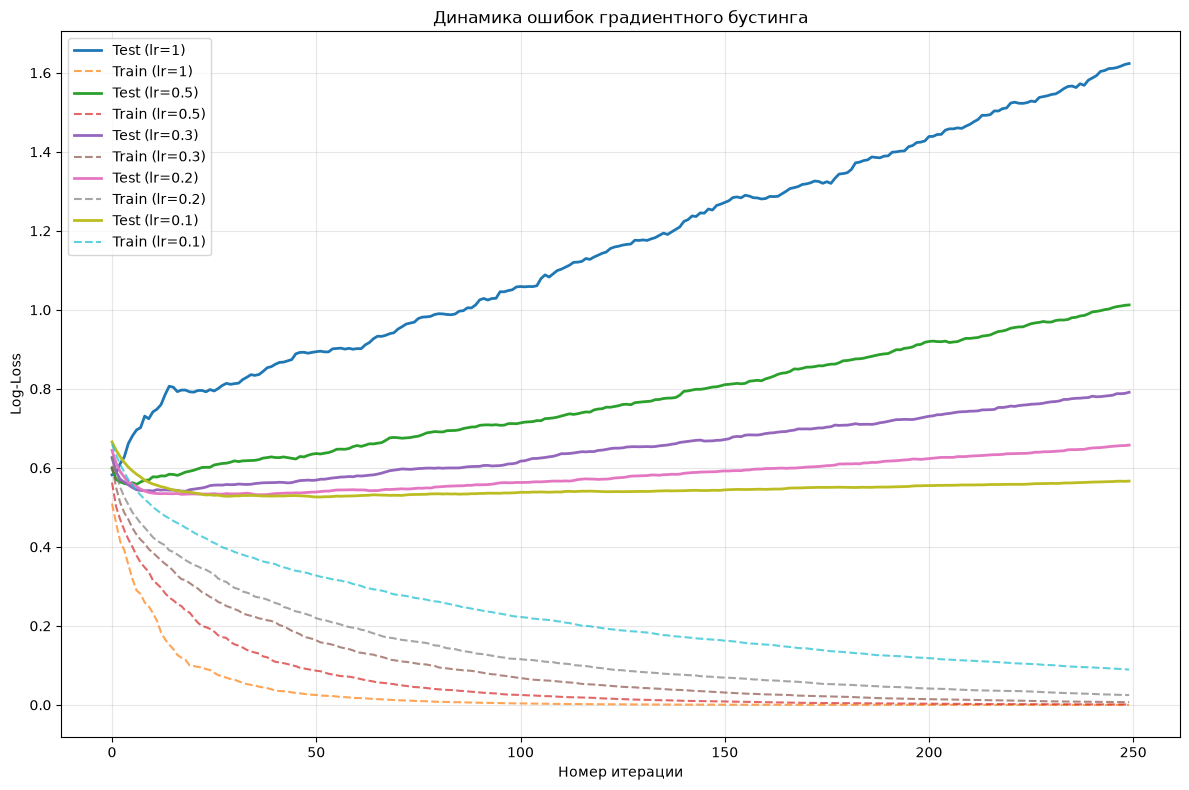


Ответ 1: underfitting

Ответ 2: 0.53 37

Ответ 3: 0.54

Ответы сохранены в файлы:
  gbm_ans1.txt - overfitting/underfitting
  gbm_ans2.txt - best_loss best_iter
  gbm_ans3.txt - rf_loss


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import log_loss

print("Загрузка данных...")
data = pd.read_csv('gbm-data.csv')
y = data.iloc[:, 0].values
X = data.iloc[:, 1:].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.8, random_state=241
)
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def compute_loss_on_iterations(model, X, y):
    loss_history = []
    for pred in model.staged_decision_function(X):
        prob = sigmoid(pred)
        loss = log_loss(y, prob)
        loss_history.append(loss)
    return np.array(loss_history)

learning_rates = [1, 0.5, 0.3, 0.2, 0.1]
results = {}

plt.figure(figsize=(12, 8))

for lr in learning_rates:
    print(f"\nОбучение с learning_rate = {lr}")
    gbm = GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=lr,
        random_state=241,
        verbose=False
    )
    gbm.fit(X_train, y_train)
    
    train_loss = compute_loss_on_iterations(gbm, X_train, y_train)
    test_loss = compute_loss_on_iterations(gbm, X_test, y_test)
    
    best_iter = np.argmin(test_loss) + 1
    best_loss = test_loss[best_iter - 1]
    
    results[lr] = {
        'train_loss': train_loss,
        'test_loss': test_loss,
        'best_iter': best_iter,
        'best_loss': best_loss
    }
    
    print(f"  Лучший test loss: {best_loss:.4f} на итерации {best_iter}")
    
    plt.plot(test_loss, label=f'Test (lr={lr})', linewidth=2)
    plt.plot(train_loss, '--', label=f'Train (lr={lr})', alpha=0.7)

plt.xlabel('Номер итерации')
plt.ylabel('Log-Loss')
plt.title('Динамика ошибок градиентного бустинга')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gbm_analysis.png', dpi=300)
plt.show()

test_loss_02 = results[0.2]['test_loss']
min_idx = np.argmin(test_loss_02)

if len(test_loss_02) > min_idx + 10:
    avg_before = np.mean(test_loss_02[min_idx-5:min_idx])
    avg_after = np.mean(test_loss_02[min_idx+1:min_idx+6])
    overfitting = avg_after > avg_before
else:
    overfitting = False

answer1 = "overfitting" if overfitting else "underfitting"
print(f"\nОтвет 1: {answer1}")

best_iter_02 = results[0.2]['best_iter']
best_loss_02 = results[0.2]['best_loss']
print(f"\nОтвет 2: {best_loss_02:.2f} {best_iter_02}")

rf = RandomForestClassifier(
    n_estimators=best_iter_02,
    random_state=241,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_loss = log_loss(y_test, rf_proba)

print(f"\nОтвет 3: {rf_loss:.2f}")

with open('gbm_ans1.txt', 'w') as f:
    f.write(answer1)

with open('gbm_ans2.txt', 'w') as f:
    f.write(f"{best_loss_02:.2f} {best_iter_02}")

with open('gbm_ans3.txt', 'w') as f:
    f.write(f"{rf_loss:.2f}")

print("\nОтветы сохранены в файлы:")
print("  gbm_ans1.txt - overfitting/underfitting")
print("  gbm_ans2.txt - best_loss best_iter")
print("  gbm_ans3.txt - rf_loss")